# STIS default-parameter investigation

Before we loop the extractor over ~140 SNe, we need to know whether MAST's default extraction
parameters are trustworthy or whether we need our own trace-finding first.

Key parameters from the STIS x1d header:
- `A2CENTER` / `EXTRLOCY` - trace center row (should sit on the SN, ~894 for E1 on OF8B, ~898 for ofrs)
- `EXTRSIZE` - aperture height in pixels
- `BK1OFFST`, `BK2OFFST` - background region offsets from trace
- `BK1SIZE`, `BK2SIZE` - background region heights

We know from the 2024iss test: A2CENTER=894 was correct; bg at -300/-320 was way off the chip.
Question here: are the defaults consistent across *other* SNe, or does each visit pick its own center?

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.time import Time
from astroquery.mast import Observations
from glob import glob
import os

pd.set_option('display.max_rows', 200); pd.set_option('display.width', 200)

In [4]:
base = '../data/2024iss/mastDownload/HST/of8b02010'
sx1_pipe = f'{base}/of8b02010_sx1.fits'
x1d_ours = f'{base}/230_x1d_ours.fits'
crj      = f'{base}/of8b02010_crj.fits'

def read_xpars(x1d_path):
    h0 = fits.getheader(x1d_path, 0)
    t  = fits.getdata(x1d_path, 1)    # FITS_rec, not a single row
    r  = t[0]
    cols = t.columns.names
    return {
        'A2CENTER':  float(r['A2CENTER']),
        'EXTRLOCY':  float(r['EXTRLOCY'][512]),      # per-column trace row at dispersion mid
        'EXTRSIZE':  float(r['EXTRSIZE']) if 'EXTRSIZE' in cols else np.nan,
        'BK1OFFST':  float(r['BK1OFFST']) if 'BK1OFFST' in cols else np.nan,
        'BK2OFFST':  float(r['BK2OFFST']) if 'BK2OFFST' in cols else np.nan,
        'BK1SIZE':   float(r['BK1SIZE'])  if 'BK1SIZE'  in cols else np.nan,
        'BK2SIZE':   float(r['BK2SIZE'])  if 'BK2SIZE'  in cols else np.nan,
        'APERTURE':  str(h0.get('APERTURE','')),
        'OPT_ELEM':  str(h0.get('OPT_ELEM','')),
    }

ref_pipe = read_xpars(sx1_pipe)
ref_ours = read_xpars(x1d_ours)
print('2024iss G230LB (of8b02010)')
print('  MAST pipeline sx1:', ref_pipe)
print('  our x1d:          ', ref_ours)


2024iss G230LB (of8b02010)
  MAST pipeline sx1: {'A2CENTER': 894.02685546875, 'EXTRLOCY': 894.02685546875, 'EXTRSIZE': 7.0, 'BK1OFFST': -300.0, 'BK2OFFST': -320.0, 'BK1SIZE': 5.0, 'BK2SIZE': 5.0, 'APERTURE': '52X0.2', 'OPT_ELEM': 'G230LB'}
  our x1d:           {'A2CENTER': 894.0264892578125, 'EXTRLOCY': 894.0264892578125, 'EXTRSIZE': 7.0, 'BK1OFFST': -300.0, 'BK2OFFST': -320.0, 'BK1SIZE': 5.0, 'BK2SIZE': 5.0, 'APERTURE': '52X0.2', 'OPT_ELEM': 'G230LB'}


In [5]:
# helper: overlay extraction + bg regions on the 2D crj image. taken from stis_sandbox.
def show_extraction_regions(x1d_path, crj_path, title='', row=0, xrange=(100, 900)):
    sci = fits.getdata(crj_path, 1)
    t   = fits.getdata(x1d_path, 1)[0]
    a2  = float(fits.getheader(x1d_path, 0).get('A2CENTER', t['EXTRLOCY'][512]))
    ely = t['EXTRLOCY'] - 1          # 1-indexed -> 0-indexed
    es  = float(t['EXTRSIZE'])
    b1o, b2o = float(t['BK1OFFST']), float(t['BK2OFFST'])
    b1s, b2s = float(t['BK1SIZE']),  float(t['BK2SIZE'])
    
    prof = np.nanmedian(sci[:, xrange[0]:xrange[1]], axis=1)
    xs   = np.arange(sci.shape[1])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 2D image with aperture lines
    vlo, vhi = np.nanpercentile(sci, [1, 99])
    axes[0].imshow(sci, origin='lower', aspect='auto', vmin=vlo, vmax=vhi, cmap='gray')
    cx = sci.shape[1] // 2
    axes[0].axhline(ely[cx], color='red', lw=1.5, label=f'trace (a2={a2:.1f})')
    axes[0].axhline(ely[cx] - es/2, color='red', lw=0.8, ls='--')
    axes[0].axhline(ely[cx] + es/2, color='red', lw=0.8, ls='--')
    axes[0].axhline(ely[cx] + b1o,  color='orange', lw=1, label=f'bg1 ctr (off {b1o:+.0f})')
    axes[0].axhline(ely[cx] + b1o - b1s/2, color='orange', lw=0.6, ls=':')
    axes[0].axhline(ely[cx] + b1o + b1s/2, color='orange', lw=0.6, ls=':')
    axes[0].axhline(ely[cx] + b2o,  color='yellow', lw=1, label=f'bg2 ctr (off {b2o:+.0f})')
    axes[0].axhline(ely[cx] + b2o - b2s/2, color='yellow', lw=0.6, ls=':')
    axes[0].axhline(ely[cx] + b2o + b2s/2, color='yellow', lw=0.6, ls=':')
    axes[0].set_title(f'2D crj  {title}')
    axes[0].legend(fontsize=8, loc='upper left')
    axes[0].set_xlim(0, sci.shape[1]); axes[0].set_ylim(a2 - 60, a2 + 60)
    
    # spatial profile
    axes[1].plot(prof, np.arange(len(prof)), color='k', lw=0.8)
    axes[1].axhline(ely[cx],          color='red',    lw=1.5, label='trace')
    axes[1].axhline(ely[cx] + b1o,    color='orange', lw=1,   label=f'bg1 ctr')
    axes[1].axhline(ely[cx] + b2o,    color='yellow', lw=1,   label=f'bg2 ctr')
    axes[1].set_ylim(a2 - 120, a2 + 120)
    axes[1].set_xlabel('median counts'); axes[1].set_title('spatial profile')
    axes[1].legend(fontsize=8)
    
    plt.suptitle(title, fontsize=10)
    plt.tight_layout(); plt.show()

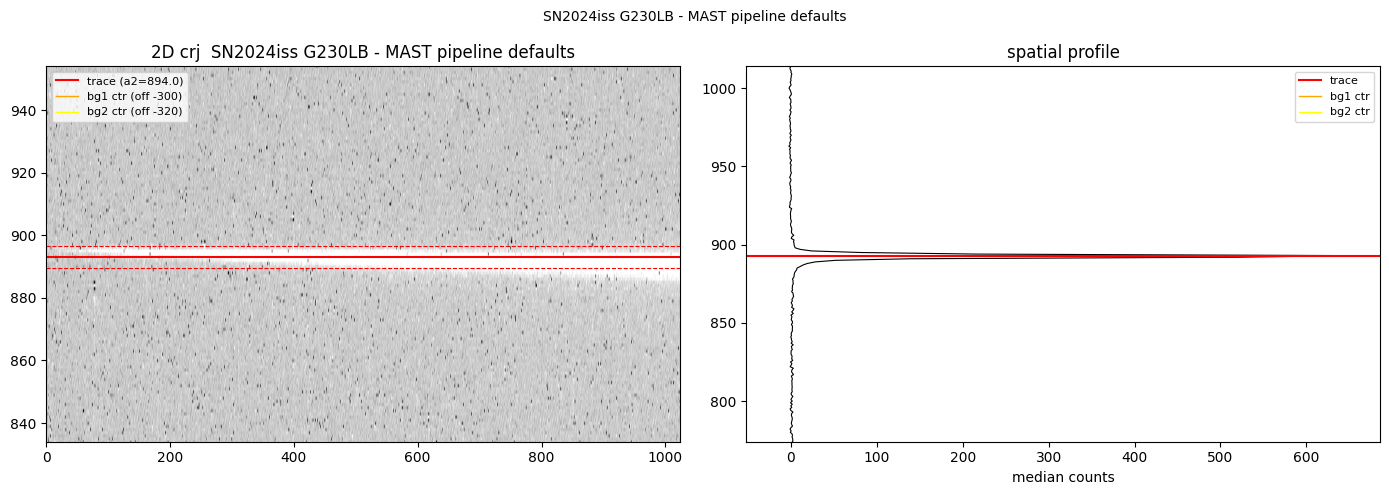

In [6]:
# 2024iss reference: MAST pipeline default. known: a2center=894, bg at -300/-320 (both off-chip)
show_extraction_regions(sx1_pipe, crj, title='SN2024iss G230LB - MAST pipeline defaults')

In [8]:
cat = pd.read_csv('../output/uv_sn_catalog.csv')
stis_cat = cat[cat['instr'].astype(str).str.contains('STIS', na=False)].copy()
print(f'{len(stis_cat)} SNe with STIS coverage in catalog')
print(stis_cat[['name','instr','gratings','n_spec']].head(20).to_string(index=False))


138 SNe with STIS coverage in catalog
              name    instr                                   gratings  n_spec
LMC-SN1987A-STIS-2     STIS  G140L;G140M;G230L;G430L;G430M;G750L;G750M     203
         SN2023IXF COS;STIS       G140L;G230L;G230LB;G430L;G750L;G750M     133
          SN2010JL COS;STIS       G130M;G140L;G160M;G230L;G230LB;G430L      72
          PTF11KLY     STIS             G140L;G230L;G230LB;G430L;G750L      58
            M82-SN     STIS                          G230L;G430L;G750L      45
          PTF12GZK     STIS                          G230L;G430L;G750L      36
           SN1998S     STIS                    E230M;G140L;G230L;G430L      34
         SN-2005IP     STIS                                G140L;G230L      32
        ASASSN14LP     STIS                          G230L;G430L;G750L      32
             PSN07     STIS                          G230L;G430L;G750L      32
          SN2013DY     STIS                          G230L;G430L;G750L      32
           TES

In [9]:
# pick a few targets with G230LB that we can download sx1 headers from quickly
# use catalog names that MAST resolves cleanly
targets_to_check = ['SN2023ixf', 'SN2010jl', 'SN2021yja', 'SN2009ip', 'SN2002ap']

rows = []
for tgt in targets_to_check:
    try:
        obs = Observations.query_criteria(objectname=tgt, radius='0.05 deg',
                                          obs_collection='HST', dataproduct_type='spectrum',
                                          instrument_name='STIS/CCD')
        df = obs.to_pandas()
        df = df[df['filters'].astype(str).str.contains('G230LB', na=False)]
        df['target_key'] = tgt
        rows.append(df)
        print(f'{tgt}: {len(df)} G230LB exposures')
    except Exception as e:
        print(f'{tgt}: query failed - {e}')

hits = pd.concat(rows, ignore_index=True)
print(f'\n{len(hits)} total G230LB CCD obs')
print(hits[['target_key','obs_id','proposal_id','t_exptime']].to_string(index=False))


SN2023ixf: 56 G230LB exposures
SN2010jl: 11 G230LB exposures
SN2021yja: 17 G230LB exposures
SN2009ip: 2 G230LB exposures
SN2002ap: 3 G230LB exposures

89 total G230LB CCD obs
target_key    obs_id proposal_id   t_exptime
 SN2023ixf of4301010       17313 1158.000000
 SN2023ixf oezt030b0       17205    0.768224
 SN2023ixf oezt020a0       17205  768.000000
 SN2023ixf oezt02010       17205  648.000000
 SN2023ixf oezt05050       17205  768.000000
 SN2023ixf oezt04080       17205  768.000000
 SN2023ixf oezt030a0       17205    0.768225
 SN2023ixf oezt020c0       17205  768.000000
 SN2023ixf oezt01010       17205    0.768224
 SN2023ixf of4303010       17313 1232.000000
 SN2023ixf oezt010b0       17205  768.000000
 SN2023ixf oezt01080       17205  769.000000
 SN2023ixf oezt01030       17205  648.000000
 SN2023ixf oezt03010       17205  648.000000
 SN2023ixf oezt020b0       17205  768.000000
 SN2023ixf oezt03050       17205  769.000000
 SN2023ixf oezt010c0       17205  768.000000
 SN2023ixf oezt

In [10]:
# download one sx1 per target (just pick one good exposure - we want the header params, not the spectrum)
os.makedirs('../data/automation_test', exist_ok=True)

# one rep per target with texp > 500s, deduped by target
reps = (hits[hits['t_exptime'] > 500]
        .drop_duplicates('target_key')
        .reset_index(drop=True))
print('Representatives to download:')
print(reps[['target_key','obs_id','t_exptime']].to_string(index=False))

downloaded = {}   # target_key -> local sx1 path
for _, row in reps.iterrows():
    oid = str(row['obs_id'])
    pl  = Observations.get_product_list(Observations.query_criteria(obs_id=[oid]))
    sx1 = pl[[str(f).endswith('_sx1.fits') for f in pl['productFilename']]]
    if len(sx1) == 0:
        print(f'{oid}: no sx1'); continue
    outdir = f'../data/automation_test/{oid}'
    Observations.download_products(sx1, download_dir=outdir, mrp_only=False, verbose=False)
    paths = glob(f'{outdir}/mastDownload/HST/*/*_sx1.fits')
    if paths:
        downloaded[row['target_key']] = paths[0]
        print(f"  {row['target_key']} ({oid}): {os.path.basename(paths[0])}")

print(f'\n{len(downloaded)} sx1 downloaded')


Representatives to download:
target_key    obs_id  t_exptime
 SN2023ixf of4301010     1158.0
  SN2010jl obk004030     1100.0
 SN2021yja oec802050     1544.0
  SN2009ip oc6501010      600.0
  SN2002ap o6gl43020     2599.8
  SN2023ixf (of4301010): of4301010_sx1.fits
  SN2010jl (obk004030): obk004030_sx1.fits
  SN2021yja (oec802050): oec802050_sx1.fits
  SN2009ip (oc6501010): oc6501010_sx1.fits
o6gl43020: no sx1

4 sx1 downloaded


In [11]:
# build the parameter comparison table: read xpars from each downloaded sx1 + 2024iss reference
param_rows = []

# 2024iss ref (already in hand)
param_rows.append({'target': 'SN2024iss', **read_xpars(sx1_pipe)})

# the downloaded ones
for tgt, path in downloaded.items():
    try:
        param_rows.append({'target': tgt, **read_xpars(path)})
    except Exception as e:
        print(f'{tgt}: {e}')

pars = pd.DataFrame(param_rows)
# keep just the key cols for display
disp = pars[['target','APERTURE','OPT_ELEM','A2CENTER','EXTRLOCY','EXTRSIZE','BK1OFFST','BK2OFFST','BK1SIZE','BK2SIZE']]
print('STIS G230LB extraction parameters -- MAST pipeline defaults across SNe:\n')
print(disp.to_string(index=False))
print(f'\nA2CENTER range: {pars["A2CENTER"].min():.1f} - {pars["A2CENTER"].max():.1f}')
print(f'BK1OFFST unique values: {sorted(pars["BK1OFFST"].unique())}')
print(f'BK2OFFST unique values: {sorted(pars["BK2OFFST"].unique())}')


STIS G230LB extraction parameters -- MAST pipeline defaults across SNe:

   target APERTURE OPT_ELEM   A2CENTER   EXTRLOCY  EXTRSIZE  BK1OFFST  BK2OFFST  BK1SIZE  BK2SIZE
SN2024iss   52X0.2   G230LB 894.026855 894.026855       7.0    -300.0    -320.0      5.0      5.0
SN2023ixf   52X0.2   G230LB 893.641968 893.641968       7.0    -300.0    -320.0      5.0      5.0
 SN2010jl   52X0.2   G230LB 912.889343 912.889343       7.0    -300.0    -320.0      5.0      5.0
SN2021yja   52X0.2   G230LB 893.339417 893.339417       7.0    -300.0    -320.0      5.0      5.0
 SN2009ip   52X0.2   G230LB 893.404297 893.404297       7.0    -300.0    -320.0      5.0      5.0

A2CENTER range: 893.3 - 912.9
BK1OFFST unique values: [np.float64(-300.0)]
BK2OFFST unique values: [np.float64(-320.0)]


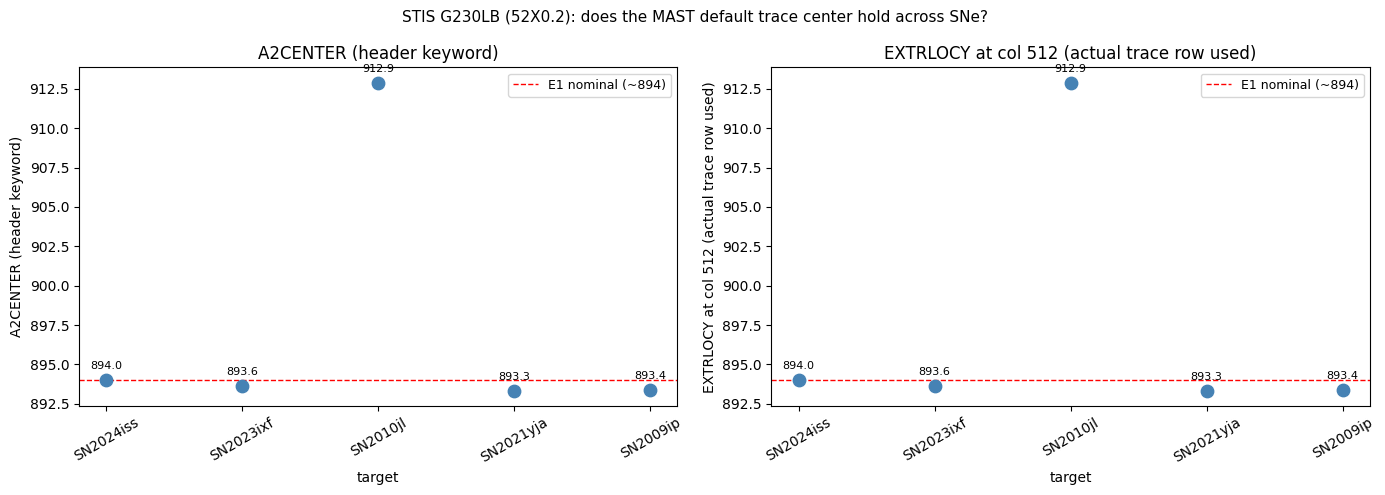

In [13]:
# A2CENTER scatter: do all SNe using 52X0.2 land near the E1 nominal ~894?
# SN2010jl is an outlier at 912 -- worth investigating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in [
    (axes[0], 'A2CENTER', 'A2CENTER (header keyword)'),
    (axes[1], 'EXTRLOCY', 'EXTRLOCY at col 512 (actual trace row used)'),
]:
    ax.scatter(pars['target'], pars[col], s=80, zorder=3, c='steelblue')
    ax.axhline(894, color='red', ls='--', lw=1, label='E1 nominal (~894)')
    ax.set_xlabel('target'); ax.set_ylabel(label)
    ax.set_title(label); ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    # annotate each point with the value
    for _, r in pars.iterrows():
        ax.annotate(f'{r[col]:.1f}', (r['target'], r[col]), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('STIS G230LB (52X0.2): does the MAST default trace center hold across SNe?', fontsize=11)
plt.tight_layout(); plt.show()


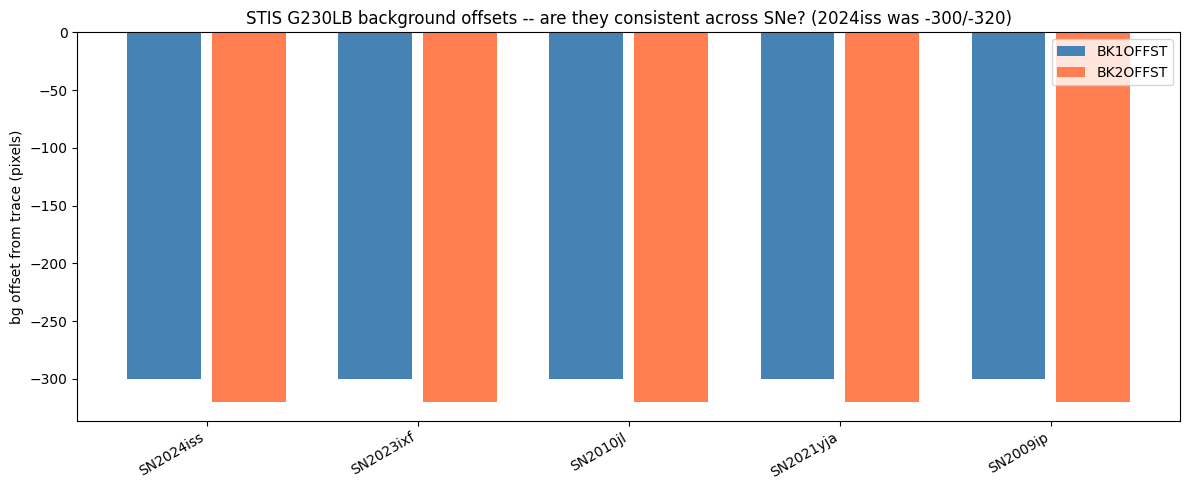

In [14]:
# bg offsets: are they fixed across programs, or does each visit choose its own?
# we know 2024iss had -300/-320, both off-chip. is that a universal default or per-visit?
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(pars))
ax.bar(x - 0.2, pars['BK1OFFST'], 0.35, label='BK1OFFST', color='steelblue')
ax.bar(x + 0.2, pars['BK2OFFST'], 0.35, label='BK2OFFST', color='coral')
ax.set_xticks(x); ax.set_xticklabels(pars['target'], rotation=30, ha='right')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('bg offset from trace (pixels)')
ax.set_title('STIS G230LB background offsets -- are they consistent across SNe? (2024iss was -300/-320)')
ax.legend()
plt.tight_layout(); plt.show()

In [15]:
# for the 2023ixf visits we already have (of43 main epochs), read params from our own x1d
# and compare to the MAST pipeline - same setup, can we see if the MAST trace center matches ours?
of43_x1d = sorted(glob('../data/2023ixf/epochs/day*/mastDownload/HST/*/of*010_x1d.fits'))  # g230lb
ixf_rows = []
for p in of43_x1d:
    h0 = fits.getheader(p, 0)
    t  = fits.getdata(p, 1)[0]
    ixf_rows.append({
        'file':     os.path.basename(p),
        'aperture': str(h0.get('APERTURE','')),
        'A2CENTER': float(h0.get('A2CENTER', np.nan)),
        'EXTRLOCY': round(float(t['EXTRLOCY'][512]), 1),
        'EXTRSIZE': float(t['EXTRSIZE']),
        'BK1OFFST': float(t['BK1OFFST']),
        'BK2OFFST': float(t['BK2OFFST']),
    })
print('SN2023ixf of43 main epochs -- our own x1d extraction params:')
print(pd.DataFrame(ixf_rows).to_string(index=False))

SN2023ixf of43 main epochs -- our own x1d extraction params:
              file aperture  A2CENTER  EXTRLOCY  EXTRSIZE  BK1OFFST  BK2OFFST
ofoz01010_x1d.fits   52X0.2       NaN     411.1      11.0    -300.0     300.0
ofoz02010_x1d.fits   52X0.2       NaN     521.5      11.0    -300.0     300.0
of4301010_x1d.fits   52X0.2       NaN     893.6       7.0    -300.0    -320.0
of8801010_x1d.fits   52X0.2       NaN     370.2      11.0    -300.0     300.0
of4302010_x1d.fits   52X0.2       NaN     893.3       7.0    -300.0    -320.0
of4303010_x1d.fits   52X0.2       NaN     893.8       7.0    -300.0    -320.0
ofbp01010_x1d.fits   52X0.2       NaN     403.9      11.0    -300.0     300.0
ofbp02010_x1d.fits   52X0.2       NaN     404.0      11.0    -300.0     300.0
ofbp04010_x1d.fits   52X0.2       NaN     522.0      11.0    -300.0     300.0
ofbp03010_x1d.fits   52X0.2       NaN     402.8      11.0    -300.0     300.0
ofbp05010_x1d.fits   52X0.2       NaN     523.6      11.0    -300.0     300.0
ofg

In [16]:
# SN2010jl A2CENTER=912 is suspicious (E1 nominal ~894, that's 18px off).
# download the crj for obk004030 and plot the spatial profile to see where the trace actually is.
oid_jl = 'obk004030'
pl = Observations.get_product_list(Observations.query_criteria(obs_id=[oid_jl]))
crj_prod = pl[[str(f).endswith('_crj.fits') for f in pl['productFilename']]]
if len(crj_prod):
    outdir = f'../data/automation_test/{oid_jl}'
    Observations.download_products(crj_prod, download_dir=outdir, mrp_only=False, verbose=False)
    crj_jl = glob(f'{outdir}/mastDownload/HST/*/*_crj.fits')[0]
    sx1_jl = glob(f'../data/automation_test/{oid_jl}/mastDownload/HST/*/*_sx1.fits')[0]
    print('downloaded', os.path.basename(crj_jl))
else:
    print('no crj for obk004030 - checking flt')
    flt_prod = pl[[str(f).endswith('_flt.fits') for f in pl['productFilename']]]
    Observations.download_products(flt_prod, download_dir=outdir, mrp_only=False, verbose=False)
    crj_jl = glob(f'{outdir}/mastDownload/HST/*/*_flt.fits')[0]
    print('downloaded flt instead:', os.path.basename(crj_jl))


downloaded obk004030_crj.fits


SN2010jl peak row (0-indexed) near E1: 912  (pipeline used 912-1=911)


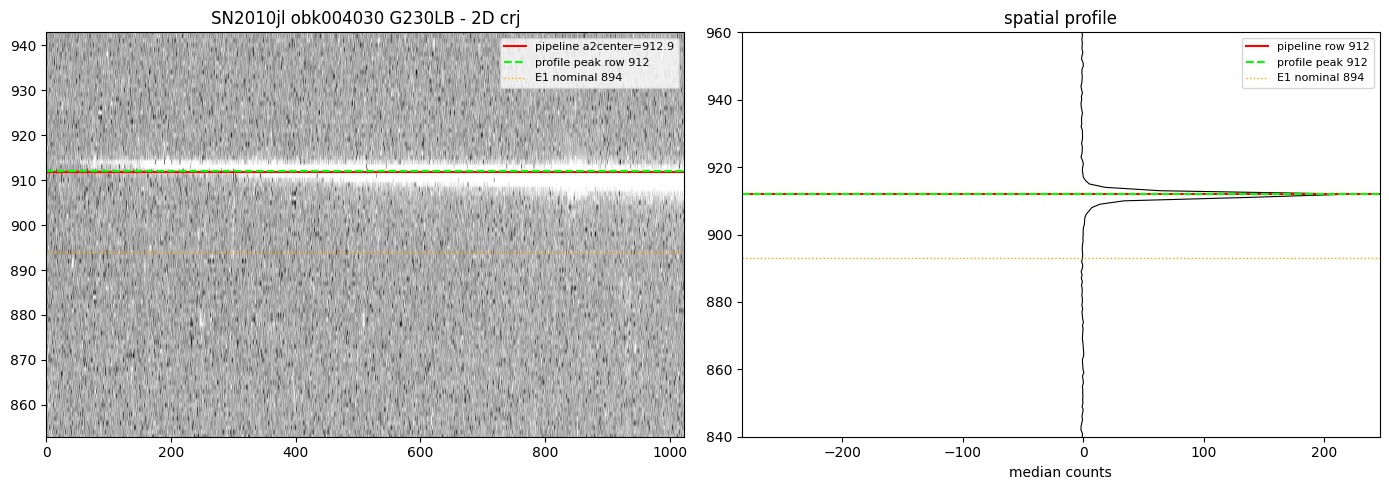

In [17]:
# plot the SN2010jl 2D crj with the pipeline extraction overlay.
# if the true trace peak is near 912, the pipeline was right; if it's near 894, the pipeline missed.
# also show the spatial profile to see where the flux actually peaks.
sci_jl = fits.getdata(crj_jl, 1)
prof_jl = np.nanmedian(sci_jl[:, 100:900], axis=1)
pk = np.argmax(prof_jl[800:1000]) + 800    # search near top (E1 region)
print(f'SN2010jl peak row (0-indexed) near E1: {pk}  (pipeline used 912-1=911)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vlo, vhi = np.nanpercentile(sci_jl, [2, 98])
axes[0].imshow(sci_jl, origin='lower', aspect='auto', vmin=vlo, vmax=vhi, cmap='gray')
a2_jl = 912.9  # from pars table
axes[0].axhline(a2_jl - 1, color='red', lw=1.5, label=f'pipeline a2center={a2_jl:.1f}')
axes[0].axhline(pk, color='lime', lw=1.5, ls='--', label=f'profile peak row {pk}')
axes[0].axhline(894, color='orange', lw=1, ls=':', label='E1 nominal 894')
axes[0].set_ylim(a2_jl - 60, a2_jl + 30); axes[0].set_xlim(0, sci_jl.shape[1])
axes[0].set_title(f'SN2010jl obk004030 G230LB - 2D crj'); axes[0].legend(fontsize=8)

axes[1].plot(prof_jl, np.arange(len(prof_jl)), color='k', lw=0.8)
axes[1].axhline(a2_jl - 1, color='red', lw=1.5, label=f'pipeline row {a2_jl-1:.0f}')
axes[1].axhline(pk, color='lime', lw=1.5, ls='--', label=f'profile peak {pk}')
axes[1].axhline(893, color='orange', lw=1, ls=':', label='E1 nominal 894')
axes[1].set_ylim(840, 960); axes[1].set_xlabel('median counts')
axes[1].set_title('spatial profile'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


**Conclusions -> `docs/pipeline_phase3.md` P3.5 for the full write-up.**

Short version: A2CENTER is reliable for bright sources but varies by program (893-894 for recent E1 props, ~912 for obk); BK1OFFST/BK2OFFST are hardcoded at -300/-320 everywhere and wrong for E1 CCD sources. Automation loop needs: (1) profile-peak trace fallback for faint sources, (2) bg offsets placed relative to the found trace center.


**What this notebook checks** (full conclusions in `docs/pipeline_phase3.md` P3.5):
- A2CENTER: does the pipeline trace center hold across SNe, or does it vary by program?
- BK1OFFST/BK2OFFST: hardcoded XTRACTAB default or adaptive per visit?
- SN2010jl sanity check: does A2CENTER=912 match the actual 2D trace?
